In [1]:
%pip install qiskit qiskit-ibm-runtime
%pip install qiskit-aer
%pip install 'qiskit[visualization]'

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
import math
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)


In [3]:
pi = math.pi
q = QuantumRegister(2,'q')
c = ClassicalRegister(2,'c')
qc = QuantumCircuit(q,c)

In [4]:
QiskitRuntimeService.save_account(channel="ibm_quantum", token="Your token here", overwrite=True, set_as_default=True)
service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy(min_num_qubits=127)

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
circuit_qc = pm.run(qc)
noise_model = NoiseModel.from_backend(backend)


Grover's

In [5]:
qc.h(range(2))
qc.x(range(2))
qc.h(q[1])
qc.cx(q[0], q[1])
qc.h(q[1])
qc.x(q[0])
qc.h(q[0])
qc.x(q[1])
qc.h(q[1])
qc.x(q[0])
qc.x(q[1])
qc.h(q[1])
qc.cx(q[0], q[1])
qc.h(q[1])
qc.x(q[0])
qc.h(q[0])
qc.x(q[1])
qc.h(q[1])
qc.measure_all()

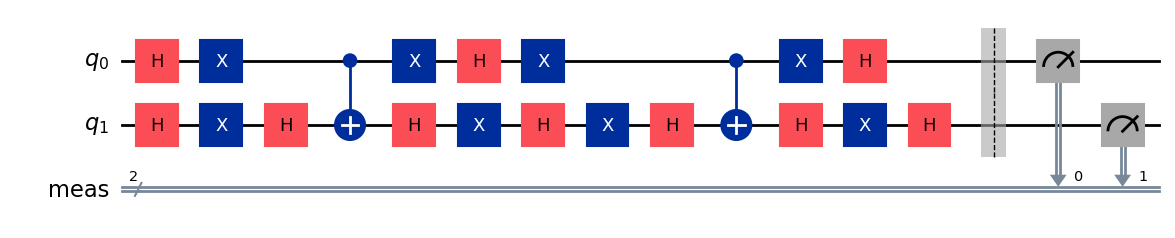

In [6]:
qc.draw('mpl', fold=False, idle_wires=False)

Run Simulation

In [7]:
simulator = AerSimulator(noise_model=noise_model)
result = simulator.run(qc).result()

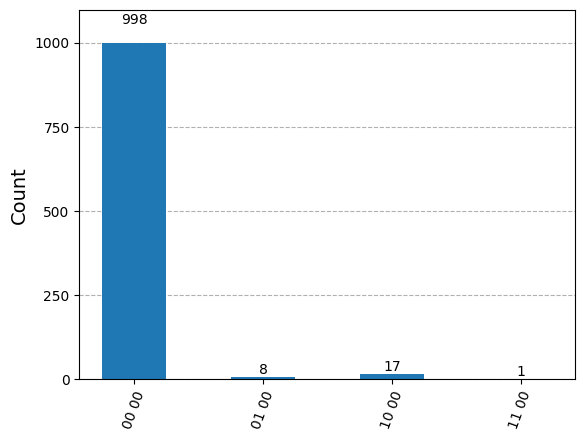

In [8]:
counts = result.get_counts(qc)
plot_histogram(counts)

Run on IBM Quantum Computer

In [23]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1_024
result = sampler.run([circuit_qc]).result()

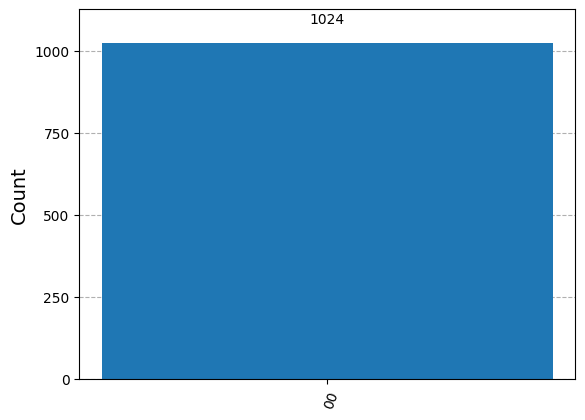

In [24]:
dist = result[0].data.c.get_counts()
plot_histogram(dist)